In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import pandas as pd

In [2]:
# Specify the filename for the .pkl file
filename = "collision_stats_final.pkl"
# Load the dictionary back from the .pkl file
with open(filename, "rb") as f:
    stats = pickle.load(f)

# Specify the filename for the .pkl file
filename = "collision_fcnn.pkl"
# Load the dictionary back from the .pkl file
with open(filename, "rb") as f:
    stats_fcnn = pickle.load(f)

filename = "collision_fcnn2.pkl"
with open(filename, "rb") as f:
    stats_fcnn2 = pickle.load(f)

filename = "collision_fcnn3.pkl"
with open(filename, "rb") as f:
    stats_fcnn3 = pickle.load(f)

filename = "collision_fcnn4.pkl"
with open(filename, "rb") as f:
    stats_fcnn4 = pickle.load(f)

filename = "collision_fcnn5.pkl"
with open(filename, "rb") as f:
    stats_fcnn5 = pickle.load(f)

filename = "collision_fcnn6.pkl"
with open(filename, "rb") as f:
    stats_fcnn6 = pickle.load(f)

In [3]:
iterations = list(stats.keys())
all_methods = list(stats[0].keys())
percentages = list(stats[0]['FES'].keys())
metrics = list(stats[0]['FES'][1.0].keys())

In [4]:
iterations2 = list(stats_fcnn2.keys())
all_methods2 = list(stats_fcnn2[0].keys())

In [5]:
iterations3 = list(stats_fcnn3.keys())
all_methods3 = list(stats_fcnn3[0].keys())

In [6]:
iterations4 = list(stats_fcnn4.keys())
all_methods4 = list(stats_fcnn4[0].keys())

In [7]:
iterations5 = list(stats_fcnn5.keys())
all_methods5 = list(stats_fcnn5[0].keys())

iterations6 = list(stats_fcnn6.keys())
all_methods6 = list(stats_fcnn6[0].keys())

In [8]:
median_stats = {}
for method_key in all_methods:
    median_stats[method_key] = {}
    for percentage_key in percentages:
        median_stats[method_key][percentage_key] = {}
        for metric_key in metrics:
            if percentage_key != 1.0 and method_key == "FCNN":
                median_stats[method_key][percentage_key][metric_key] = np.median([
                stats_fcnn[iter][method_key][percentage_key][metric_key] 
                for iter in iterations 
                if stats_fcnn[iter][method_key][percentage_key][metric_key] is not None ])
            else:
                median_stats[method_key][percentage_key][metric_key] = np.median([
                stats[iter][method_key][percentage_key][metric_key] 
                for iter in iterations 
                if stats[iter][method_key][percentage_key][metric_key] is not None ])  

In [9]:
median_stats2 = {}
for method_key in all_methods2:
    median_stats2[method_key] = {}
    for percentage_key in percentages:
        median_stats2[method_key][percentage_key] = {}
        for metric_key in metrics:
            median_stats2[method_key][percentage_key][metric_key] = np.median([
                stats_fcnn2[iter][method_key][percentage_key][metric_key] 
                for iter in iterations2 
                if stats_fcnn2[iter][method_key][percentage_key][metric_key] is not None ])

c:\Users\aless\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\aless\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [10]:
median_stats3 = {}
for method_key in all_methods3:
    median_stats3[method_key] = {}
    for percentage_key in percentages:
        median_stats3[method_key][percentage_key] = {}
        for metric_key in metrics:
            median_stats3[method_key][percentage_key][metric_key] = np.median([
                stats_fcnn3[iter][method_key][percentage_key][metric_key] 
                for iter in iterations3 
                if stats_fcnn3[iter][method_key][percentage_key][metric_key] is not None ])

In [11]:
median_stats4 = {}
for method_key in all_methods4:
    median_stats4[method_key] = {}
    for percentage_key in percentages:
        median_stats4[method_key][percentage_key] = {}
        for metric_key in metrics:
            median_stats4[method_key][percentage_key][metric_key] = np.median([
                stats_fcnn4[iter][method_key][percentage_key][metric_key] 
                for iter in iterations4 
                if stats_fcnn4[iter][method_key][percentage_key][metric_key] is not None ])

In [12]:
median_stats5 = {}
for method_key in all_methods5:
    median_stats5[method_key] = {}
    for percentage_key in percentages:
        median_stats5[method_key][percentage_key] = {}
        for metric_key in metrics:
            median_stats5[method_key][percentage_key][metric_key] = np.median([
                stats_fcnn5[iter][method_key][percentage_key][metric_key] 
                for iter in iterations5 
                if stats_fcnn5[iter][method_key][percentage_key][metric_key] is not None ])
            
median_stats6 = {}
for method_key in all_methods6:
    median_stats6[method_key] = {}
    for percentage_key in percentages:
        median_stats6[method_key][percentage_key] = {}
        for metric_key in metrics:
            median_stats6[method_key][percentage_key][metric_key] = np.median([
                stats_fcnn6[iter][method_key][percentage_key][metric_key] 
                for iter in iterations6 
                if stats_fcnn6[iter][method_key][percentage_key][metric_key] is not None ])

## How does the reduction affects the efficiency?

In [13]:
time_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        time_df.loc[m][p] = round(median_stats[m][p]['time'],2)
time_df_t = time_df.transpose()
time_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\327068377.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df.loc[m][p] = round(median_stats[m][p]['time'],2)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,251.5,52.76,78.07,64.09,67.9,55.55,251.28
0.3,367.21,157.64,191.67,190.43,195.48,161.25,312.54
0.5,366.1,262.78,303.96,310.28,318.43,267.66,374.7
0.7,383.18,367.0,408.02,423.62,433.1,371.16,436.25
0.9,386.03,471.83,522.8,532.15,546.48,478.67,499.62
1.0,529.73,529.73,529.73,529.73,529.73,529.73,529.73


In [14]:
time_df_t1 = time_df_t["FCNN"].iloc[:-1]
time_df_t1

0.1     251.5
0.3    367.21
0.5     366.1
0.7    383.18
0.9    386.03
Name: FCNN, dtype: object

In [15]:
time_df2 = pd.DataFrame(index=all_methods2, columns=percentages)
for m in all_methods2:
    for p in percentages:
        time_df2.loc[m][p] = round(median_stats2[m][p]['time'],2)
time_df_t2 = time_df2.transpose().iloc[:, 0]
time_df_t2

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\548861910.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df2.loc[m][p] = round(median_stats2[m][p]['time'],2)


0.1    295.77
0.3    431.84
0.5     435.1
0.7    441.43
0.9    453.16
1.0       NaN
Name: FCNN, dtype: object

In [16]:
time_df3 = pd.DataFrame(index=all_methods3, columns=percentages)
for m in all_methods3:
    for p in percentages:
        time_df3.loc[m][p] = round(median_stats3[m][p]['time'],2)
time_df_t3 = time_df3.transpose().iloc[:, 0]
time_df_t3

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1715617236.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df3.loc[m][p] = round(median_stats3[m][p]['time'],2)


0.1     245.1
0.3    370.94
0.5    368.13
0.7    388.81
0.9    386.32
1.0       NaN
Name: FCNN, dtype: object

In [17]:
time_df4 = pd.DataFrame(index=all_methods4, columns=percentages)
for m in all_methods4:
    for p in percentages:
        time_df4.loc[m][p] = round(median_stats4[m][p]['time'],2)
time_df_t4 = time_df4.transpose().iloc[:, 0]
time_df_t4

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\230753302.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df4.loc[m][p] = round(median_stats4[m][p]['time'],2)


0.1     252.1
0.3    378.76
0.5    378.44
0.7    396.44
0.9    402.37
1.0       NaN
Name: FCNN, dtype: object

In [18]:
time_df5 = pd.DataFrame(index=all_methods5, columns=percentages)
for m in all_methods5:
    for p in percentages:
        time_df5.loc[m][p] = round(median_stats5[m][p]['time'],2)
time_df_t5 = time_df5.transpose().iloc[:, 0]
time_df_t5

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\4127840243.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df5.loc[m][p] = round(median_stats5[m][p]['time'],2)


0.1    226.77
0.3    351.62
0.5    345.21
0.7    366.59
0.9    366.85
1.0       NaN
Name: FCNN, dtype: object

In [19]:
time_df6 = pd.DataFrame(index=all_methods6, columns=percentages)
for m in all_methods6:
    for p in percentages:
        time_df6.loc[m][p] = round(median_stats6[m][p]['time'],2)
time_df_t6 = time_df6.transpose().iloc[:, 0]
time_df_t6

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\3099656584.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  time_df6.loc[m][p] = round(median_stats6[m][p]['time'],2)


0.1    226.26
0.3    350.81
0.5    346.65
0.7    364.31
0.9    369.49
1.0       NaN
Name: FCNN, dtype: object

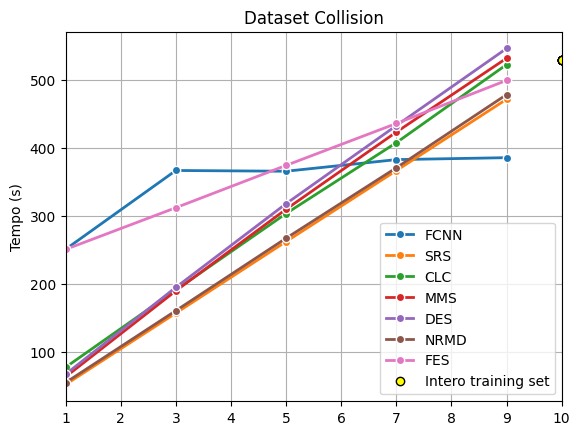

In [66]:
for idx, row in time_df.iterrows():
    x_vals = time_df.columns * 10
    y_vals = row.values

    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)

    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.ylabel('Tempo (s)')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

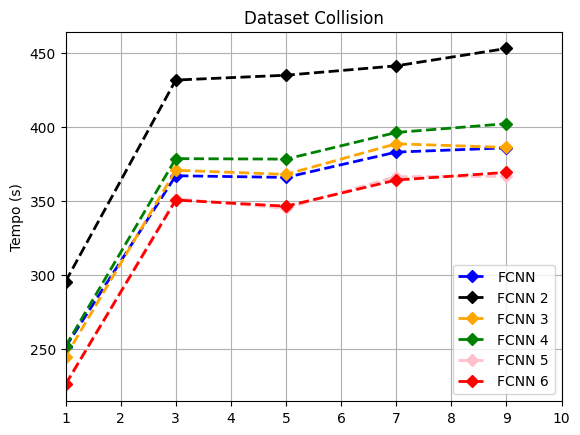

In [21]:
"""for idx, row in time_df.iterrows():
    plt.plot(
        time_df.columns * 10,
        row,
        label=idx,
        marker='o',
        markersize=6,
        markeredgecolor='white',
        linewidth=2
    )"""

plt.plot(
    time_df_t1.index * 10,           
    time_df_t1.values,               
    label='FCNN',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='blue'                  
)

plt.plot(
    time_df_t2.index * 10,           
    time_df_t2.values,               
    label='FCNN 2',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='black'                  
)

plt.plot(
    time_df_t3.index * 10,           
    time_df_t3.values,               
    label='FCNN 3',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='orange'                  
)

plt.plot(
    time_df_t4.index * 10,           
    time_df_t4.values,               
    label='FCNN 4',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='green'                  
)

plt.plot(
    time_df_t5.index * 10,           
    time_df_t5.values,               
    label='FCNN 5',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='pink'                  
)

plt.plot(
    time_df_t6.index * 10,           
    time_df_t6.values,               
    label='FCNN 6',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='red'                  
)

plt.ylabel('Tempo (s)')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

In [22]:
carbon_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        carbon_df.loc[m][p] = round(median_stats[m][p]['carbon'] * 1000,3)
carbon_df_t = carbon_df.transpose()
carbon_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\171476848.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  carbon_df.loc[m][p] = round(median_stats[m][p]['carbon'] * 1000,3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,2.176,0.459,0.682,0.557,0.592,0.483,2.188
0.3,3.198,1.372,1.675,1.656,1.713,1.401,2.72
0.5,3.186,2.286,2.635,2.7,2.791,2.327,3.275
0.7,3.338,3.199,3.547,3.683,3.786,3.232,3.83
0.9,3.359,4.137,4.538,4.629,4.75,4.167,4.356
1.0,4.6,4.6,4.6,4.6,4.6,4.6,4.6


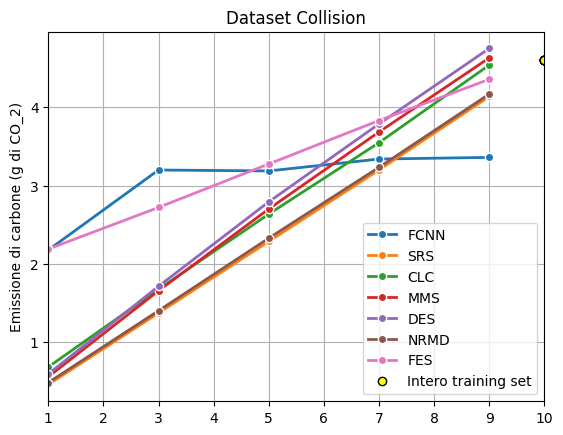

In [ ]:
for idx, row in carbon_df.iterrows():
    x_vals = carbon_df.columns * 10
    y_vals = row.values

    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)

    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.ylabel('Emissione di carbone (g di CO_2)')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

## How $\varepsilon$-representative are the reduced datasets?

In [24]:
epsilon_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        epsilon_df.loc[m][p] = round(median_stats[m][p]['epsilon'],3)
epsilon_df_t = epsilon_df.transpose()
epsilon_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2445719397.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df.loc[m][p] = round(median_stats[m][p]['epsilon'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.711,0.625,0.529,0.4,0.628,0.959,0.823
0.3,0.68,0.55,0.58,0.332,0.533,0.944,0.67
0.5,0.749,0.55,0.459,0.293,0.533,0.85,0.573
0.7,0.749,0.55,0.419,0.244,0.511,0.754,0.474
0.9,0.758,0.427,0.334,0.22,0.433,0.612,0.392
1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
epsilon_df_t1 = epsilon_df_t["FCNN"].iloc[:-1]
epsilon_df_t1

0.1    0.711
0.3     0.68
0.5    0.749
0.7    0.749
0.9    0.758
Name: FCNN, dtype: object

In [26]:
epsilon_df2 = pd.DataFrame(index=all_methods2, columns=percentages)
for m in all_methods2:
    for p in percentages:
        epsilon_df2.loc[m][p] = round(median_stats2[m][p]['epsilon'],3)
epsilon_df_t2 = epsilon_df2.transpose()["FCNN"]
epsilon_df_t2

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2567253668.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df2.loc[m][p] = round(median_stats2[m][p]['epsilon'],3)


0.1    0.711
0.3     0.68
0.5    0.749
0.7    0.749
0.9    0.758
1.0      NaN
Name: FCNN, dtype: object

In [27]:
epsilon_df3 = pd.DataFrame(index=all_methods3, columns=percentages)
for m in all_methods3:
    for p in percentages:
        epsilon_df3.loc[m][p] = round(median_stats3[m][p]['epsilon'],3)
epsilon_df_t3 = epsilon_df3.transpose()["FCNN"]
epsilon_df_t3

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2175107225.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df3.loc[m][p] = round(median_stats3[m][p]['epsilon'],3)


0.1    0.711
0.3     0.68
0.5    0.749
0.7    0.749
0.9    0.758
1.0      NaN
Name: FCNN, dtype: object

In [28]:
epsilon_df4 = pd.DataFrame(index=all_methods4, columns=percentages)
for m in all_methods4:
    for p in percentages:
        epsilon_df4.loc[m][p] = round(median_stats4[m][p]['epsilon'],3)
epsilon_df_t4 = epsilon_df4.transpose()["FCNN"]
epsilon_df_t4

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2485397757.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df4.loc[m][p] = round(median_stats4[m][p]['epsilon'],3)


0.1    0.711
0.3     0.68
0.5    0.749
0.7    0.749
0.9    0.758
1.0      NaN
Name: FCNN, dtype: object

In [29]:
epsilon_df5 = pd.DataFrame(index=all_methods5, columns=percentages)
for m in all_methods5:
    for p in percentages:
        epsilon_df5.loc[m][p] = round(median_stats5[m][p]['epsilon'],3)
epsilon_df_t5 = epsilon_df5.transpose()["FCNN"]
epsilon_df_t5

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1436544640.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df5.loc[m][p] = round(median_stats5[m][p]['epsilon'],3)


0.1    0.788
0.3     0.68
0.5    0.749
0.7    0.749
0.9    0.758
1.0      NaN
Name: FCNN, dtype: object

In [30]:
epsilon_df6 = pd.DataFrame(index=all_methods6, columns=percentages)
for m in all_methods6:
    for p in percentages:
        epsilon_df6.loc[m][p] = round(median_stats6[m][p]['epsilon'],3)
epsilon_df_t6 = epsilon_df6.transpose()["FCNN"]
epsilon_df_t6

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1586760632.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_df6.loc[m][p] = round(median_stats6[m][p]['epsilon'],3)


0.1    0.788
0.3     0.68
0.5    0.749
0.7    0.749
0.9    0.758
1.0      NaN
Name: FCNN, dtype: object

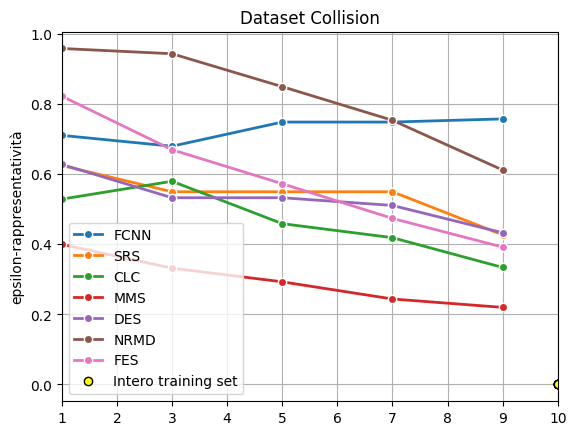

In [69]:
for idx, row in epsilon_df.iterrows():
    x_vals = epsilon_df.columns * 10
    y_vals = row.values

    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)

    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.ylabel('epsilon-rappresentatività')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

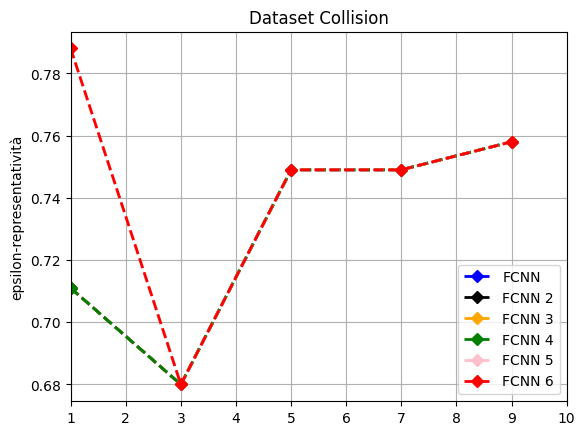

In [31]:
"""for idx, row in epsilon_df.iterrows():
    plt.plot(epsilon_df.columns * 10, row, label=idx, marker='o',
        markersize=6,
        markeredgecolor='white',
        linewidth=2)"""

plt.plot(
    epsilon_df_t1.index * 10,           
    epsilon_df_t1.values,               
    label='FCNN',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='blue'                  
)
  
plt.plot(
    epsilon_df_t2.index * 10,           
    epsilon_df_t2.values,               
    label='FCNN 2',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='black'                  
)

plt.plot(
    epsilon_df_t3.index * 10,           
    epsilon_df_t3.values,               
    label='FCNN 3',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='orange'                  
)

plt.plot(
    epsilon_df_t4.index * 10,           
    epsilon_df_t4.values,               
    label='FCNN 4',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='green'                  
)

plt.plot(
    epsilon_df_t5.index * 10,           
    epsilon_df_t5.values,               
    label='FCNN 5',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='pink'                  
)

plt.plot(
    epsilon_df_t6.index * 10,           
    epsilon_df_t6.values,               
    label='FCNN 6',           
    marker='D',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='red'                  
)

plt.ylabel('epsilon-representatività')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.grid()
plt.legend()
plt.show()

## How does the reduction affect the performance?

In [32]:
accuracy_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        accuracy_df.loc[m][p] = round(median_stats[m][p]['acc'],3)
accuracy_df_t = accuracy_df.transpose()
accuracy_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2707575944.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df.loc[m][p] = round(median_stats[m][p]['acc'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.911,0.894,0.874,0.865,0.897,0.823,0.646
0.3,0.895,0.895,0.893,0.881,0.896,0.854,0.865
0.5,0.898,0.912,0.892,0.896,0.915,0.862,0.914
0.7,0.905,0.915,0.905,0.902,0.914,0.901,0.918
0.9,0.898,0.911,0.909,0.913,0.916,0.904,0.912
1.0,0.905,0.905,0.905,0.905,0.905,0.905,0.905


In [33]:
accuracy_df_t1 = accuracy_df_t["FCNN"].iloc[:-1]
accuracy_df_t1

0.1    0.911
0.3    0.895
0.5    0.898
0.7    0.905
0.9    0.898
Name: FCNN, dtype: object

In [34]:
accuracy_df2 = pd.DataFrame(index=all_methods2, columns=percentages)
for m in all_methods2:
    for p in percentages:
        accuracy_df2.loc[m][p] = round(median_stats2[m][p]['acc'],3)
accuracy_df_t2 = accuracy_df2.transpose()["FCNN"]
accuracy_df_t2

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1594371784.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df2.loc[m][p] = round(median_stats2[m][p]['acc'],3)


0.1     0.91
0.3    0.899
0.5    0.913
0.7    0.907
0.9    0.909
1.0      NaN
Name: FCNN, dtype: object

In [35]:
accuracy_df3 = pd.DataFrame(index=all_methods3, columns=percentages)
for m in all_methods3:
    for p in percentages:
        accuracy_df3.loc[m][p] = round(median_stats3[m][p]['acc'],3)
accuracy_df_t3 = accuracy_df3.transpose()["FCNN"]
accuracy_df_t3

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\511647726.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df3.loc[m][p] = round(median_stats3[m][p]['acc'],3)


0.1    0.907
0.3    0.901
0.5    0.904
0.7    0.903
0.9    0.911
1.0      NaN
Name: FCNN, dtype: object

In [36]:
accuracy_df4 = pd.DataFrame(index=all_methods4, columns=percentages)
for m in all_methods4:
    for p in percentages:
        accuracy_df4.loc[m][p] = round(median_stats4[m][p]['acc'],3)
accuracy_df_t4 = accuracy_df4.transpose()["FCNN"]
accuracy_df_t4

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2719436591.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df4.loc[m][p] = round(median_stats4[m][p]['acc'],3)


0.1    0.913
0.3    0.911
0.5    0.915
0.7    0.909
0.9    0.907
1.0      NaN
Name: FCNN, dtype: object

In [37]:
accuracy_df5 = pd.DataFrame(index=all_methods5, columns=percentages)
for m in all_methods5:
    for p in percentages:
        accuracy_df5.loc[m][p] = round(median_stats5[m][p]['acc'],3)
accuracy_df_t5 = accuracy_df5.transpose()["FCNN"]
accuracy_df_t5

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\3104663618.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df5.loc[m][p] = round(median_stats5[m][p]['acc'],3)


0.1    0.912
0.3    0.893
0.5    0.912
0.7    0.906
0.9    0.904
1.0      NaN
Name: FCNN, dtype: object

In [38]:
accuracy_df6 = pd.DataFrame(index=all_methods6, columns=percentages)
for m in all_methods6:
    for p in percentages:
        accuracy_df6.loc[m][p] = round(median_stats6[m][p]['acc'],3)
accuracy_df_t6 = accuracy_df6.transpose()["FCNN"]
accuracy_df_t6

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1916793221.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  accuracy_df6.loc[m][p] = round(median_stats6[m][p]['acc'],3)


0.1    0.909
0.3    0.861
0.5    0.892
0.7    0.908
0.9    0.899
1.0      NaN
Name: FCNN, dtype: object

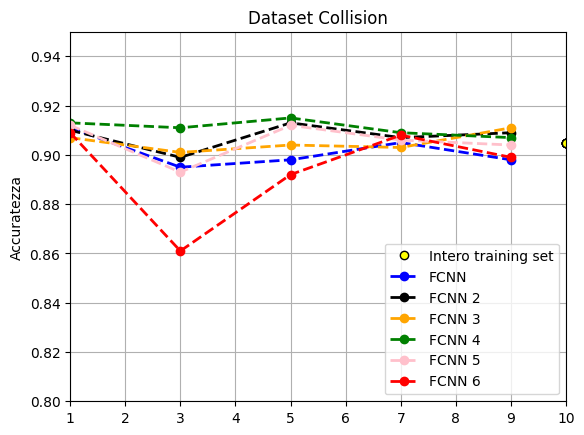

In [39]:
for idx, row in accuracy_df.iterrows():
    x_vals = accuracy_df.columns * 10
    y_vals = row.values

    """# Traccia solo fino al penultimo punto
    plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)"""

    # Disegna il punto finale separato
    plt.plot(x_vals[-1], y_vals[-1], marker='o', color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')  # Nessuna linea
    
# Aggiungi un punto fittizio solo per la legenda
plt.plot([], [], marker='o', color='yellow', markersize=6,
        markeredgecolor='black', linestyle='None',
        label='Intero training set')

plt.plot(
    accuracy_df_t1.index * 10,           
    accuracy_df_t1.values,               
    label='FCNN',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='blue'                  
)

plt.plot(
    accuracy_df_t2.index * 10,           
    accuracy_df_t2.values,               
    label='FCNN 2',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='black'                  
)

plt.plot(
    accuracy_df_t3.index * 10,           
    accuracy_df_t3.values,               
    label='FCNN 3',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='orange'                  
)

plt.plot(
    accuracy_df_t4.index * 10,           
    accuracy_df_t4.values,               
    label='FCNN 4',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='green'                  
)

plt.plot(
    accuracy_df_t5.index * 10,           
    accuracy_df_t5.values,               
    label='FCNN 5',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='pink'                  
)

plt.plot(
    accuracy_df_t6.index * 10,           
    accuracy_df_t6.values,               
    label='FCNN 6',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='red'                  
)

plt.ylabel('Accuratezza')
plt.title('Dataset Collision')
plt.xlim(1, 10)
plt.ylim(0.80, 0.95)
plt.grid()
plt.legend()
plt.show()


In [40]:
precision_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        precision_df.loc[m][p] = round(median_stats[m][p]['pre_avg'],3)
precision_df_t = precision_df.transpose()
precision_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\105675181.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  precision_df.loc[m][p] = round(median_stats[m][p]['pre_avg'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.91,0.885,0.861,0.851,0.89,0.819,0.646
0.3,0.91,0.881,0.879,0.898,0.882,0.856,0.881
0.5,0.884,0.903,0.878,0.882,0.911,0.848,0.915
0.7,0.911,0.905,0.892,0.888,0.914,0.889,0.916
0.9,0.885,0.9,0.897,0.906,0.914,0.89,0.907
1.0,0.892,0.892,0.892,0.892,0.892,0.892,0.892


In [41]:
precision_df_t1 = precision_df_t["FCNN"].iloc[:-1]
precision_df_t1

0.1     0.91
0.3     0.91
0.5    0.884
0.7    0.911
0.9    0.885
Name: FCNN, dtype: object

In [42]:
precision_df2 = pd.DataFrame(index=all_methods2, columns=percentages)
for m in all_methods2:
    for p in percentages:
        precision_df2.loc[m][p] = round(median_stats2[m][p]['pre_avg'],3)
precision_df_t2 = precision_df2.transpose()["FCNN"]
precision_df_t2

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2825229393.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  precision_df2.loc[m][p] = round(median_stats2[m][p]['pre_avg'],3)


0.1    0.912
0.3    0.911
0.5    0.903
0.7    0.901
0.9    0.906
1.0      NaN
Name: FCNN, dtype: object

In [43]:
precision_df3 = pd.DataFrame(index=all_methods3, columns=percentages)
for m in all_methods3:
    for p in percentages:
        precision_df3.loc[m][p] = round(median_stats3[m][p]['pre_avg'],3)
precision_df_t3 = precision_df3.transpose()["FCNN"]
precision_df_t3

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\862016497.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  precision_df3.loc[m][p] = round(median_stats3[m][p]['pre_avg'],3)


0.1    0.896
0.3    0.909
0.5    0.891
0.7    0.904
0.9      0.9
1.0      NaN
Name: FCNN, dtype: object

In [44]:
precision_df4 = pd.DataFrame(index=all_methods4, columns=percentages)
for m in all_methods4:
    for p in percentages:
        precision_df4.loc[m][p] = round(median_stats4[m][p]['pre_avg'],3)
precision_df_t4 = precision_df4.transpose()["FCNN"]
precision_df_t4

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\3768657112.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  precision_df4.loc[m][p] = round(median_stats4[m][p]['pre_avg'],3)


0.1    0.905
0.3    0.908
0.5    0.909
0.7    0.897
0.9    0.897
1.0      NaN
Name: FCNN, dtype: object

In [45]:
precision_df5 = pd.DataFrame(index=all_methods5, columns=percentages)
for m in all_methods5:
    for p in percentages:
        precision_df5.loc[m][p] = round(median_stats5[m][p]['pre_avg'],3)
precision_df_t5 = precision_df5.transpose()["FCNN"]
precision_df_t5

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1006400456.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  precision_df5.loc[m][p] = round(median_stats5[m][p]['pre_avg'],3)


0.1    0.908
0.3    0.902
0.5    0.901
0.7    0.894
0.9    0.901
1.0      NaN
Name: FCNN, dtype: object

In [46]:
precision_df6 = pd.DataFrame(index=all_methods6, columns=percentages)
for m in all_methods6:
    for p in percentages:
        precision_df6.loc[m][p] = round(median_stats6[m][p]['pre_avg'],3)
precision_df_t6 = precision_df6.transpose()["FCNN"]
precision_df_t6

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1337497793.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  precision_df6.loc[m][p] = round(median_stats6[m][p]['pre_avg'],3)


0.1    0.897
0.3    0.895
0.5    0.878
0.7    0.901
0.9    0.894
1.0      NaN
Name: FCNN, dtype: object

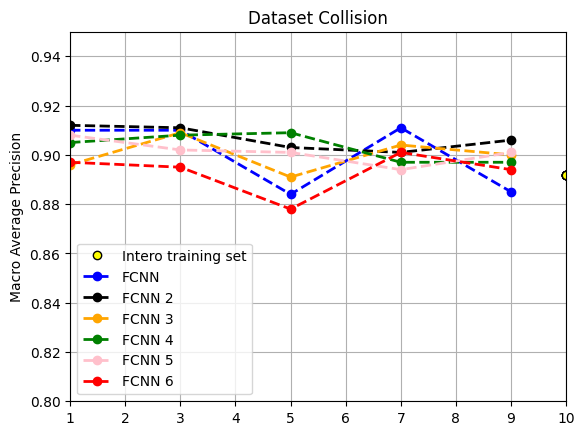

In [47]:
for idx, row in precision_df.iterrows():
    x_vals = precision_df.columns * 10
    y_vals = row.values

    """plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)"""

    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.plot(
    precision_df_t1.index * 10,           
    precision_df_t1.values,               
    label='FCNN',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='blue'                  
)

plt.plot(
    precision_df_t2.index * 10,           
    precision_df_t2.values,               
    label='FCNN 2',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='black'                  
)

plt.plot(
    precision_df_t3.index * 10,           
    precision_df_t3.values,               
    label='FCNN 3',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='orange'                  
)

plt.plot(
    precision_df_t4.index * 10,           
    precision_df_t4.values,               
    label='FCNN 4',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='green'                  
)

plt.plot(
    precision_df_t5.index * 10,           
    precision_df_t5.values,               
    label='FCNN 5',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='pink'                  
)

plt.plot(
    precision_df_t6.index * 10,           
    precision_df_t6.values,               
    label='FCNN 6',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='red'                  
)

plt.ylabel('Macro Average Precision')
plt.title('Dataset Collision')
plt.xlim(1, 10)
plt.ylim(0.80, 0.95)
plt.grid()
plt.legend()
plt.show()


In [48]:
recall_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        recall_df.loc[m][p] = round(median_stats[m][p]['rec_avg'],3)
recall_df_t = recall_df.transpose()
recall_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\4002456481.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  recall_df.loc[m][p] = round(median_stats[m][p]['rec_avg'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.893,0.884,0.888,0.872,0.884,0.784,0.5
0.3,0.862,0.904,0.902,0.842,0.899,0.819,0.823
0.5,0.905,0.905,0.9,0.905,0.902,0.873,0.896
0.7,0.879,0.911,0.91,0.91,0.896,0.896,0.902
0.9,0.901,0.908,0.91,0.904,0.901,0.911,0.899
1.0,0.91,0.91,0.91,0.91,0.91,0.91,0.91


In [49]:
recall_df_t1 = recall_df_t["FCNN"].iloc[:-1]
recall_df_t1

0.1    0.893
0.3    0.862
0.5    0.905
0.7    0.879
0.9    0.901
Name: FCNN, dtype: object

In [50]:
recall_df2 = pd.DataFrame(index=all_methods2, columns=percentages)
for m in all_methods2:
    for p in percentages:
        recall_df2.loc[m][p] = round(median_stats2[m][p]['rec_avg'],3)
recall_df_t2 = recall_df2.transpose()["FCNN"]
recall_df_t2

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1295994189.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  recall_df2.loc[m][p] = round(median_stats2[m][p]['rec_avg'],3)


0.1     0.89
0.3    0.868
0.5    0.908
0.7    0.895
0.9    0.893
1.0      NaN
Name: FCNN, dtype: object

In [51]:
recall_df3 = pd.DataFrame(index=all_methods3, columns=percentages)
for m in all_methods3:
    for p in percentages:
        recall_df3.loc[m][p] = round(median_stats3[m][p]['rec_avg'],3)
recall_df_t3 = recall_df3.transpose()["FCNN"]
recall_df_t3

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\144025281.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  recall_df3.loc[m][p] = round(median_stats3[m][p]['rec_avg'],3)


0.1    0.903
0.3    0.873
0.5    0.905
0.7    0.881
0.9     0.91
1.0      NaN
Name: FCNN, dtype: object

In [52]:
recall_df4 = pd.DataFrame(index=all_methods4, columns=percentages)
for m in all_methods4:
    for p in percentages:
        recall_df4.loc[m][p] = round(median_stats4[m][p]['rec_avg'],3)
recall_df_t4 = recall_df4.transpose()["FCNN"]
recall_df_t4

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\931687336.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  recall_df4.loc[m][p] = round(median_stats4[m][p]['rec_avg'],3)


0.1    0.904
0.3    0.896
0.5    0.905
0.7    0.909
0.9      0.9
1.0      NaN
Name: FCNN, dtype: object

In [53]:
recall_df5 = pd.DataFrame(index=all_methods5, columns=percentages)
for m in all_methods5:
    for p in percentages:
        recall_df5.loc[m][p] = round(median_stats5[m][p]['rec_avg'],3)
recall_df_t5 = recall_df5.transpose()["FCNN"]
recall_df_t5

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1921099955.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  recall_df5.loc[m][p] = round(median_stats5[m][p]['rec_avg'],3)


0.1    0.898
0.3    0.864
0.5     0.91
0.7    0.903
0.9    0.886
1.0      NaN
Name: FCNN, dtype: object

In [54]:
recall_df6 = pd.DataFrame(index=all_methods6, columns=percentages)
for m in all_methods6:
    for p in percentages:
        recall_df6.loc[m][p] = round(median_stats6[m][p]['rec_avg'],3)
recall_df_t6 = recall_df6.transpose()["FCNN"]
recall_df_t6

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\2071729196.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  recall_df6.loc[m][p] = round(median_stats6[m][p]['rec_avg'],3)


0.1    0.905
0.3    0.809
0.5    0.902
0.7    0.897
0.9    0.883
1.0      NaN
Name: FCNN, dtype: object

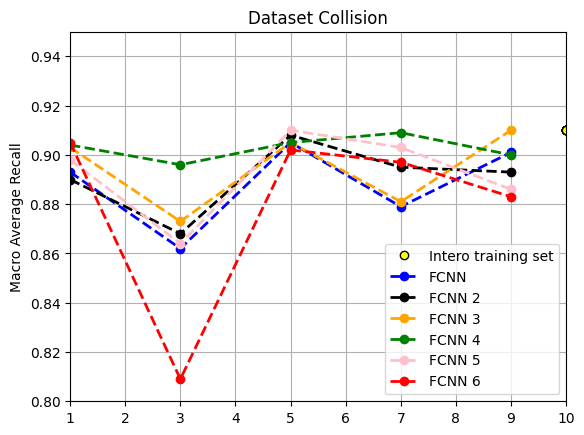

In [55]:
for idx, row in recall_df.iterrows():
    x_vals = recall_df.columns * 10
    y_vals = row.values
    """plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)"""

    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.plot(
    recall_df_t1.index * 10,           
    recall_df_t1.values,               
    label='FCNN',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='blue'                  
)

plt.plot(
    recall_df_t2.index * 10,           
    recall_df_t2.values,               
    label='FCNN 2',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='black'                  
)

plt.plot(
    recall_df_t3.index * 10,           
    recall_df_t3.values,               
    label='FCNN 3',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='orange'                  
)

plt.plot(
    recall_df_t4.index * 10,           
    recall_df_t4.values,               
    label='FCNN 4',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='green'                  
)

plt.plot(
    recall_df_t5.index * 10,           
    recall_df_t5.values,               
    label='FCNN 5',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='pink'                  
)

plt.plot(
    recall_df_t6.index * 10,           
    recall_df_t6.values,               
    label='FCNN 6',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='red'                  
)

plt.ylabel('Macro Average Recall')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

In [56]:
f1score_df = pd.DataFrame(index=all_methods, columns=percentages)
for m in all_methods:
    for p in percentages:
        f1score_df.loc[m][p] = round(median_stats[m][p]['f1_avg'],3)
f1score_df_t = f1score_df.transpose()
f1score_df_t

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\374755532.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df.loc[m][p] = round(median_stats[m][p]['f1_avg'],3)


,FCNN,SRS,CLC,MMS,DES,NRMD,FES
0.1,0.901,0.884,0.868,0.858,0.887,0.796,0.785
0.3,0.879,0.889,0.887,0.861,0.889,0.832,0.842
0.5,0.892,0.904,0.886,0.89,0.906,0.855,0.904
0.7,0.892,0.908,0.899,0.896,0.904,0.893,0.908
0.9,0.891,0.904,0.903,0.905,0.907,0.898,0.903
1.0,0.899,0.899,0.899,0.899,0.899,0.899,0.899


In [57]:
f1score_df_t1 = f1score_df_t["FCNN"].iloc[:-1]
f1score_df_t1

0.1    0.901
0.3    0.879
0.5    0.892
0.7    0.892
0.9    0.891
Name: FCNN, dtype: object

In [58]:
f1score_df2 = pd.DataFrame(index=all_methods2, columns=percentages)
for m in all_methods2:
    for p in percentages:
        f1score_df2.loc[m][p] = round(median_stats2[m][p]['f1_avg'],3)
f1score_df_t2 = f1score_df2.transpose()["FCNN"]
f1score_df_t2

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1881407256.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df2.loc[m][p] = round(median_stats2[m][p]['f1_avg'],3)


0.1    0.899
0.3    0.884
0.5    0.905
0.7    0.898
0.9    0.898
1.0      NaN
Name: FCNN, dtype: object

In [59]:
f1score_df3 = pd.DataFrame(index=all_methods3, columns=percentages)
for m in all_methods3:
    for p in percentages:
        f1score_df3.loc[m][p] = round(median_stats3[m][p]['f1_avg'],3)
f1score_df_t3 = f1score_df3.transpose()["FCNN"]
f1score_df_t3

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1216217129.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df3.loc[m][p] = round(median_stats3[m][p]['f1_avg'],3)


0.1      0.9
0.3    0.887
0.5    0.897
0.7    0.891
0.9    0.904
1.0      NaN
Name: FCNN, dtype: object

In [60]:
f1score_df4 = pd.DataFrame(index=all_methods4, columns=percentages)
for m in all_methods4:
    for p in percentages:
        f1score_df4.loc[m][p] = round(median_stats4[m][p]['f1_avg'],3)
f1score_df_t4 = f1score_df4.transpose()["FCNN"]
f1score_df_t4

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\3151089479.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df4.loc[m][p] = round(median_stats4[m][p]['f1_avg'],3)


0.1    0.905
0.3    0.901
0.5    0.907
0.7    0.902
0.9    0.899
1.0      NaN
Name: FCNN, dtype: object

In [61]:
f1score_df5 = pd.DataFrame(index=all_methods5, columns=percentages)
for m in all_methods5:
    for p in percentages:
        f1score_df5.loc[m][p] = round(median_stats5[m][p]['f1_avg'],3)
f1score_df_t5 = f1score_df5.transpose()["FCNN"]
f1score_df_t5

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1820727731.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df5.loc[m][p] = round(median_stats5[m][p]['f1_avg'],3)


0.1    0.903
0.3    0.878
0.5    0.905
0.7    0.898
0.9    0.893
1.0      NaN
Name: FCNN, dtype: object

In [62]:
f1score_df6 = pd.DataFrame(index=all_methods6, columns=percentages)
for m in all_methods6:
    for p in percentages:
        f1score_df6.loc[m][p] = round(median_stats6[m][p]['f1_avg'],3)
f1score_df_t6 = f1score_df6.transpose()["FCNN"]
f1score_df_t6

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1031315106.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  f1score_df6.loc[m][p] = round(median_stats6[m][p]['f1_avg'],3)


0.1    0.901
0.3    0.832
0.5    0.886
0.7    0.899
0.9    0.888
1.0      NaN
Name: FCNN, dtype: object

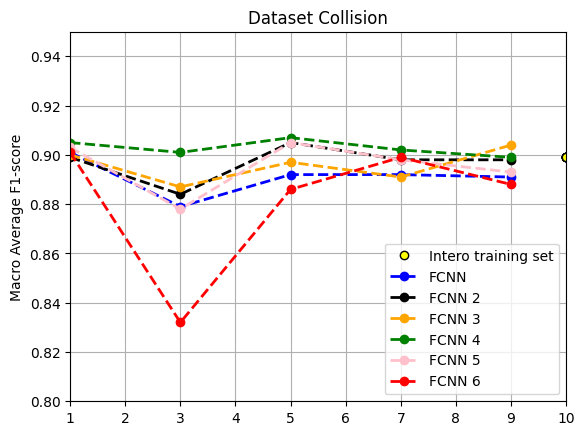

In [63]:
for idx, row in f1score_df.iterrows():
    x_vals = f1score_df.columns * 10
    y_vals = row.values

    """plt.plot(x_vals[:-1], y_vals[:-1], label=idx, marker='o',
             markersize=6, markeredgecolor='white', linewidth=2)"""

    plt.plot(x_vals[-1], y_vals[-1], marker='o',
             color='yellow',
             markersize=6, markeredgecolor='black', linestyle='None')

plt.plot([], [], marker='o', color='yellow', markersize=6,
         markeredgecolor='black', linestyle='None',
         label='Intero training set')

plt.plot(
    f1score_df_t1.index * 10,           
    f1score_df_t1.values,               
    label='FCNN',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='blue'                  
)

plt.plot(
    f1score_df_t2.index * 10,           
    f1score_df_t2.values,               
    label='FCNN 2',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='black'                  
)

plt.plot(
    f1score_df_t3.index * 10,           
    f1score_df_t3.values,               
    label='FCNN 3',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='orange'                  
)

plt.plot(
    f1score_df_t4.index * 10,           
    f1score_df_t4.values,               
    label='FCNN 4',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='green'                  
)

plt.plot(
    f1score_df_t5.index * 10,           
    f1score_df_t5.values,               
    label='FCNN 5',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='pink'                  
)

plt.plot(
    f1score_df_t6.index * 10,           
    f1score_df_t6.values,               
    label='FCNN 6',           
    marker='o',                     
    markersize=6,
    linestyle='--',                 
    linewidth=2,
    color='red'                  
)

plt.ylabel('Macro Average F1-score')
plt.title('Dataset Collision')
plt.xlim(1,10)
plt.ylim(0.80,0.95)
plt.grid()
plt.legend()
plt.show()

## Does the $\varepsilon$-representativeness affect the performance?

In [64]:
epsilon_acc_df = pd.DataFrame(index=['rho', 'p-value'], columns=percentages[:-1])
for p in percentages[:-1]:
    epsilon_values = []
    accuracy_values = []
    for iter in iterations:
        for m in all_methods:
            # Only add values if both are not None
            if stats[iter][m][p]['epsilon'] is not None and stats[iter][m][p]['acc'] is not None:
                epsilon_values.append(stats[iter][m][p]['epsilon'])
                accuracy_values.append(stats[iter][m][p]['acc'])
    rho, pvalue = spearmanr(epsilon_values, accuracy_values)
    epsilon_acc_df.loc['rho'][p], epsilon_acc_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)
epsilon_acc_df

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\1553345712.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_acc_df.loc['rho'][p], epsilon_acc_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)


,0.1,0.3,0.5,0.7,0.9
rho,-0.25,-0.57,-0.39,-0.39,-0.54
p-value,0.59,0.18,0.38,0.38,0.22


In [65]:
epsilon_f1_df = pd.DataFrame(index=['rho', 'p-value'], columns=percentages[:-1])
for p in percentages[:-1]:
    epsilon_values = []
    f1_values = []
    for iter in iterations:
        for m in all_methods:
            # Only add values if both are not None
            if stats[iter][m][p]['epsilon'] is not None and stats[iter][m][p]['f1_avg'] is not None:
                epsilon_values.append(stats[iter][m][p]['epsilon'])
                f1_values.append(stats[iter][m][p]['f1_avg'])
    rho, pvalue = spearmanr(epsilon_values, f1_values)
    epsilon_f1_df.loc['rho'][p], epsilon_f1_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)
epsilon_f1_df

C:\Users\aless\AppData\Local\Temp\ipykernel_7732\453174950.py:12: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  epsilon_f1_df.loc['rho'][p], epsilon_f1_df.loc['p-value'][p] = round(rho,2), round(pvalue,2)


,0.1,0.3,0.5,0.7,0.9
rho,-0.25,-0.54,-0.39,-0.39,-0.5
p-value,0.59,0.22,0.38,0.38,0.25
